# Price Optimization

Bu projede amaç, fiyat ile talep (satış miktarı) arasındaki ilişkiyi modelleyip, geliri maksimize eden fiyatı bulmak. Veri seti Competition_Data.csv, 100.000 satır - her satır bir mağaza/ürün/hafta kombinasyonu için fiyat, satış miktarı ve bir rakibin fiyatını içeriyor.

Referans çözüm hiç model kurmuyor: Ed = %ΔQuantity / %ΔPrice formülüyle elle bir esneklik (elasticity) hesabı yapıyor, ürünleri ortalama fiyatlarına göre Low/Medium/High segmentlerine ayırıyor, sonra sabit bir kural uyguluyor (Medium segment +%5, High segment -%10) ve toplam geliri karşılaştırıyor. Train/test ayrımı, model, ya da hiçbir sayısal değerlendirme metriği yok.

Ayrıca veri setinde önemli bir yapı var: aynı (Store_ID, Item_ID, Fiscal_Week_ID) kombinasyonu için 2 ile 32 arasında satır tekrarlanıyor - Price, Item_Quantity, Sales_Amount hepsi aynı kalıyor, sadece Competition_Price değişiyor (her satır muhtemelen farklı bir rakibin fiyatı). Bunu düzeltmeden korelasyon/regresyon yaparsak aynı gözlemi onlarca kez saymış oluruz (pseudoreplication) - bu yüzden ilk adım, veriyi (Store_ID, Item_ID, Fiscal_Week_ID) bazında tek satıra indirip Competition_Price için özet istatistik (örn. ortalama) çıkarmak.

Bu notebook'ta, referansın kural tabanlı yaklaşımı yerine gerçek bir regresyon modeli kuruyoruz: Item_Quantity'yi (talep) Price ve rakip fiyatından tahmin eden bir talep eğrisi modeli. Model eğitildikten sonra, bir ürün için fiyat aralığını tarayıp geliri (price * tahmini_talep) maksimize eden fiyatı buluyoruz - referanstaki sabit kural yerine veriye dayalı bir optimizasyon.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Regression/price_optimization')

In [2]:
df = pd.read_csv("Competition_Data.csv")
df.head(12)

,Index,Fiscal_Week_ID,Store_ID,Item_ID,Price,Item_Quantity,Sales_Amount_No_Discount,Sales_Amount,Competition_Price
0,0,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,206.44
1,1,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,158.01
2,2,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,278.03
3,3,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,222.66
4,4,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,195.32
5,5,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,108.75
6,6,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,219.64
7,7,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,100.11
8,8,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,86.10
9,9,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,231.21


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Index                     100000 non-null  int64  
 1   Fiscal_Week_ID            100000 non-null  str    
 2   Store_ID                  100000 non-null  str    
 3   Item_ID                   100000 non-null  str    
 4   Price                     100000 non-null  float64
 5   Item_Quantity             100000 non-null  int64  
 6   Sales_Amount_No_Discount  100000 non-null  float64
 7   Sales_Amount              100000 non-null  float64
 8   Competition_Price         100000 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 9.1 MB


In [4]:
df.isnull().sum()

Index                       0
Fiscal_Week_ID              0
Store_ID                    0
Item_ID                     0
Price                       0
Item_Quantity               0
Sales_Amount_No_Discount    0
Sales_Amount                0
Competition_Price           0
dtype: int64

In [5]:
group_sizes = df.groupby(["Store_ID", "Item_ID", "Fiscal_Week_ID"]).size()
group_sizes.describe()

count    8800.000000
mean       11.363636
std         4.870366
min         2.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        32.000000
dtype: float64

In [6]:
agg_df = df.groupby(["Store_ID", "Item_ID", "Fiscal_Week_ID"], as_index=False).agg(
    Price=("Price", "first"),
    Item_Quantity=("Item_Quantity", "first"),
    Sales_Amount_No_Discount=("Sales_Amount_No_Discount", "first"),
    Sales_Amount=("Sales_Amount", "first"),
    Competition_Price_min=("Competition_Price", "min"),
    Competition_Price_mean=("Competition_Price", "mean"),
    Competitor_Count=("Competition_Price", "count"),
)

agg_df.shape

(8800, 10)

In [7]:
agg_df.head()

,Store_ID,Item_ID,Fiscal_Week_ID,Price,Item_Quantity,Sales_Amount_No_Discount,Sales_Amount,Competition_Price_min,Competition_Price_mean,Competitor_Count
0,store_136,item_1,2019-11,106.69,408,2250.05,12684.92,123.35,220.271667,6
1,store_136,item_1,2019-12,99.54,397,2221.28,12700.61,63.98,178.812222,9
2,store_136,item_1,2019-13,101.97,411,2285.48,12632.90,50.70,129.702727,11
3,store_136,item_1,2019-14,107.08,426,2251.41,12623.33,87.97,219.167273,11
4,store_136,item_1,2019-15,102.35,414,2090.52,13384.32,63.10,152.080000,10


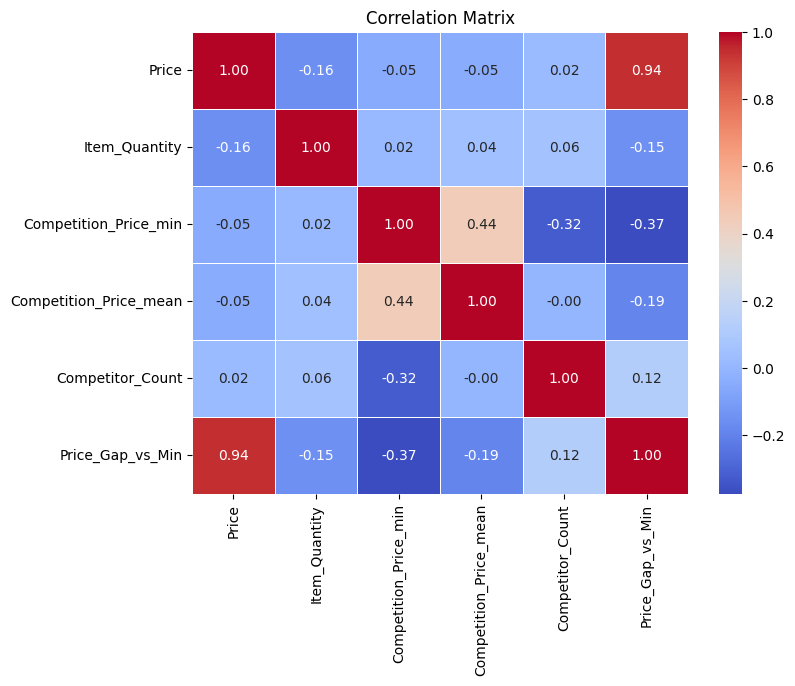

In [8]:
agg_df["Price_Gap_vs_Min"] = agg_df["Price"] - agg_df["Competition_Price_min"]

numeric_cols = ["Price", "Item_Quantity", "Competition_Price_min", "Competition_Price_mean",
                 "Competitor_Count", "Price_Gap_vs_Min"]

correlation_matrix = agg_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [9]:
candidate_features = ["Price", "Competition_Price_min", "Competition_Price_mean",
                       "Competitor_Count", "Price_Gap_vs_Min"]

correlation_report = []
for feature in candidate_features:
    r, p = pearsonr(agg_df[feature], agg_df["Item_Quantity"])
    correlation_report.append({"Feature": feature, "r": r, "p_value": p})

correlation_report_df = pd.DataFrame(correlation_report).set_index("Feature")
correlation_report_df

,r,p_value
Feature,,
Price,-0.158791,8.665655e-51
Competition_Price_min,0.015163,1.549337e-01
Competition_Price_mean,0.044145,3.434486e-05
Competitor_Count,0.056486,1.143287e-07
Price_Gap_vs_Min,-0.152384,7.229470e-47


In [10]:
item_correlations = []
for item_id, group in agg_df.groupby("Item_ID"):
    if len(group) >= 10 and group["Price"].std() > 0:
        r, p = pearsonr(group["Price"], group["Item_Quantity"])
        item_correlations.append({"Item_ID": item_id, "n": len(group), "r": r, "p_value": p})

item_correlations_df = pd.DataFrame(item_correlations)
item_correlations_df["r"].describe()

count    176.000000
mean       0.007686
std        0.137283
min       -0.437231
25%       -0.092701
50%        0.026342
75%        0.103790
max        0.314550
Name: r, dtype: float64

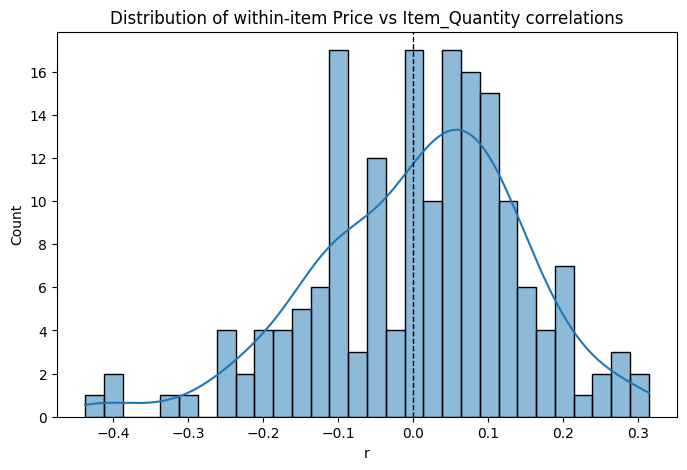

np.float64(0.045454545454545456)

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(item_correlations_df["r"], bins=30, kde=True)
plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.title("Distribution of within-item Price vs Item_Quantity correlations")
plt.xlabel("r")
plt.show()

(item_correlations_df["p_value"] < 0.05).mean()

## Kaynaktaki elasticity hatası

Önce referansın yaptığı gibi, hiç gruplama yapmadan ham df üzerinde pct_change() ile elasticity hesaplıyoruz. Satırlar zaten (Store_ID, Item_ID, Fiscal_Week_ID) bazında art arda geldiği için, bu hesap çoğunlukla aynı grup içindeki satırları (Price sabit, price_change=0) ya da bir grubun son satırından bir sonraki tamamen farklı ürünün ilk satırına geçişi (anlamsız fark) karşılaştırıyor.

In [12]:
buggy = df.copy()
buggy["price_change"] = buggy["Price"].pct_change()
buggy["qty_change"] = buggy["Item_Quantity"].pct_change()
buggy["elasticity"] = buggy["qty_change"] / buggy["price_change"]
buggy.replace([np.inf, -np.inf], np.nan, inplace=True)
buggy_elasticity = buggy["elasticity"].dropna()

print("share of rows with price_change == 0 (same-group repeats):",
      (buggy["price_change"] == 0).mean())
buggy_elasticity.describe()

share of rows with price_change == 0 (same-group repeats): 0.90008


count    9991.000000
mean        0.147094
std        24.631401
min      -732.710692
25%        -0.893601
50%         0.000000
75%         0.931124
max       875.206972
Name: elasticity, dtype: float64

## Düzeltilmiş elasticity

Şimdi aynı hesabı doğru yapıyoruz: agg_df (zaten tekilleştirilmiş) üzerinde, önce Fiscal_Week_ID'yi yıl/hafta olarak ayırıp kronolojik sıraya diziyoruz, sonra pct_change'i groupby(["Store_ID", "Item_ID"]) içinde hesaplıyoruz - böylece her ürünün kendi zaman serisi içinde, bir önceki haftaya göre değişim hesaplanmış olur, başka bir ürünle karşılaştırma yapılmaz.

In [13]:
sorted_df = agg_df.copy()
sorted_df[["Fiscal_Year", "Fiscal_Week"]] = sorted_df["Fiscal_Week_ID"].str.split("-", expand=True).astype(int)
sorted_df = sorted_df.sort_values(["Store_ID", "Item_ID", "Fiscal_Year", "Fiscal_Week"])

group_keys = ["Store_ID", "Item_ID"]
sorted_df["price_change"] = sorted_df.groupby(group_keys)["Price"].pct_change()
sorted_df["qty_change"] = sorted_df.groupby(group_keys)["Item_Quantity"].pct_change()
sorted_df["elasticity"] = sorted_df["qty_change"] / sorted_df["price_change"]
sorted_df.replace([np.inf, -np.inf], np.nan, inplace=True)
elasticity_clean = sorted_df["elasticity"].dropna()

print("rows with valid elasticity:", len(elasticity_clean), "out of", len(sorted_df))
elasticity_clean.describe()

rows with valid elasticity: 7034 out of 8800


count    7034.000000
mean       -0.690575
std        34.180151
min     -1455.268409
25%        -1.040782
50%        -0.000000
75%         0.971823
max       852.863636
Name: elasticity, dtype: float64

## Neden log dönüşümü

Ekonomideki standart talep modeli "sabit esneklik" (constant elasticity) varsayımıyla şu formda yazılır: Q = a * P^b. Bu denklemin iki tarafının logaritmasını alırsak: ln(Q) = ln(a) + b * ln(P) - yani log-log uzayında **doğrusal** bir ilişki elde ederiz. Buradaki b katsayısı tam olarak elasticity'nin kendisidir (fiyatta %1'lik değişimin talepte yol açtığı % değişim), satır satır oran hesaplamaya hiç gerek kalmadan.

İki avantajı var:
1. **İstikrar:** Az önce gördüğümüz oran-tabanlı elasticity (qty_change / price_change), payda küçükken patlıyordu. Log-log regresyon ise tüm gözlemleri en küçük kareler ile birlikte kullanır, birkaç uç değerin domine etmesine izin vermez.
2. **Yorumlanabilirlik:** Regresyon katsayısı doğrudan elasticity olarak okunur - |b| > 1 ise talep esnek (fiyat kısarsak gelir artar), |b| < 1 ise talep esnek değil (fiyat artırırsak gelir artar). Bu tam olarak "price optimization" kararı için ihtiyacımız olan sayı.

Ayrıca Price ve Item_Quantity ikisi de sağa çarpık, hep pozitif değişkenler - log dönüşüm bu çarpıklığı azaltıp OLS regresyonunun doğrusallık/homojen varyans varsayımlarına daha uygun hale getirir.

pooled log-log r: -0.13752185942599968 p-value: 2.049572205538864e-38


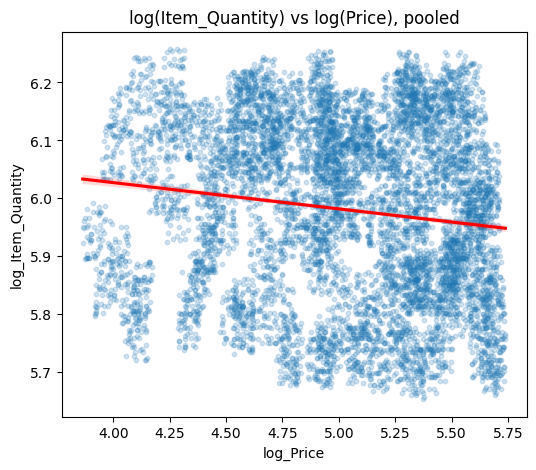

In [14]:
agg_df["log_Price"] = np.log(agg_df["Price"])
agg_df["log_Item_Quantity"] = np.log(agg_df["Item_Quantity"])

r, p = pearsonr(agg_df["log_Price"], agg_df["log_Item_Quantity"])
print("pooled log-log r:", r, "p-value:", p)

plt.figure(figsize=(6, 5))
sns.regplot(x="log_Price", y="log_Item_Quantity", data=agg_df,
            scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"})
plt.title("log(Item_Quantity) vs log(Price), pooled")
plt.show()

## Pooled model with fixed effects

Pooled log-log korelasyonun (r=-0.14) ürünler arası fiyat seviyesi farkını yakaladığını, gerçek within-item elasticity'yi yakalamadığını gördük (item-bazlı korelasyonların çoğu anlamsız çıkmıştı). pd.get_dummies + LinearRegression yaklaşımını kullanarak bunu düzeltiyoruz: log_Price'a ek olarak Item_ID ve Store_ID için dummy değişkenler ekliyoruz (drop_first=True, dummy trap'ten kaçınmak için). Bu dummy'ler her ürünün ve mağazanın kendi taban seviyesini modele "sabit etki" olarak yakalar, böylece log_Price katsayısı artık sadece aynı ürün, aynı mağaza içinde fiyat değiştiğinde talebin nasıl değiştiğini yansıtır - ürünler arası karşılaştırmadan arındırılmış olur.

In [ ]:
x = pd.concat([
    agg_df[["log_Price"]],
    pd.get_dummies(agg_df["Item_ID"], prefix="Item", drop_first=True),
    pd.get_dummies(agg_df["Store_ID"], prefix="Store", drop_first=True),
], axis=1)
y = agg_df["log_Item_Quantity"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x.shape

(8800, 185)

In [ ]:
model = LinearRegression().fit(x_train, y_train)
pred = model.predict(x_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, pred))
print("log_Price coefficient (pooled within-item/store elasticity):", model.coef_[0])

R2: 0.9626843725224792
RMSE: 0.028991188467292917
MAE: 0.024889454309036083
log_Price coefficient (pooled within-item/store elasticity): 0.007721084459290041


## Selecting price-sensitive items

Pooled fixed-effects model bize genel ortalamada fiyatın etkisi olmadığını söyledi (b≈0.008, pratikte sıfır) - bunu global bir fiyat taraması için kullanmak yanıltıcı olur. Ama item_correlations_df (daha önce hesapladık) bize hangi ürünlerde within-item fiyat-talep ilişkisinin istatistiksel olarak anlamlı olduğunu gösteriyor. Sadece p<0.05 ve negatif r olan ürünleri seçiyoruz - yani "fiyat artınca talep gerçekten düşüyor" sinyali güçlü olan, dolayısıyla bir revenue-optimizasyonu denemesinin anlamlı olacağı ürünler.

In [ ]:
price_sensitive_items = item_correlations_df[
    (item_correlations_df["p_value"] < 0.05) & (item_correlations_df["r"] < 0)
].sort_values("r")

price_sensitive_items

,Item_ID,n,r,p_value
125,item_739,50,-0.437231,0.001499
161,item_911,50,-0.410564,0.003062
60,item_410,50,-0.399889,0.004012
154,item_877,50,-0.321203,0.022940
43,item_338,50,-0.303183,0.032334


## Per-item demand curve and revenue-maximizing price

Seçtiğimiz 5 ürün için ayrı ayrı log-log model kuruyoruz (log_Item_Quantity ~ log_Price, sadece o ürünün verisiyle) - bu, cell 10'da zaten kullandığımız item-bazlı gruplama pattern'inin bir uzantısı, sadece pearsonr yerine LinearRegression fit ediyoruz ki bir tahmin denklemi elde edelim. Her ürün için fiyatı **sadece gözlenen min-max aralığında** tarıyoruz (extrapolation yapmıyoruz, çünkü modelin bu aralığın dışında geçerliliği yok) ve revenue = price * tahmini_talep değerini maksimize eden fiyatı buluyoruz.

In [ ]:
optimization_results = []

for item_id in price_sensitive_items["Item_ID"]:
    item_df = agg_df[agg_df["Item_ID"] == item_id]

    item_model = LinearRegression().fit(item_df[["log_Price"]], item_df["log_Item_Quantity"])

    price_min, price_max = item_df["Price"].min(), item_df["Price"].max()
    price_grid = pd.DataFrame({"log_Price": np.log(np.linspace(price_min, price_max, 200))})
    predicted_quantity = np.exp(item_model.predict(price_grid))
    revenue = np.exp(price_grid["log_Price"]) * predicted_quantity

    best_idx = revenue.idxmax()
    best_price = np.exp(price_grid.loc[best_idx, "log_Price"])

    last_row = item_df.sort_values("Fiscal_Week_ID").iloc[-1]
    current_price = last_row["Price"]
    current_quantity_pred = np.exp(item_model.predict(pd.DataFrame({"log_Price": [np.log(current_price)]}))[0])

    optimization_results.append({
        "Item_ID": item_id,
        "elasticity_b": item_model.coef_[0],
        "price_min": round(price_min, 2),
        "price_max": round(price_max, 2),
        "current_price": round(current_price, 2),
        "current_revenue_est": round(current_price * current_quantity_pred, 2),
        "optimal_price": round(best_price, 2),
        "optimal_revenue_est": round(revenue.loc[best_idx], 2),
    })

optimization_results_df = pd.DataFrame(optimization_results)
optimization_results_df["revenue_lift_pct"] = (
    (optimization_results_df["optimal_revenue_est"] / optimization_results_df["current_revenue_est"]) - 1
) * 100
optimization_results_df

,Item_ID,elasticity_b,price_min,price_max,current_price,current_revenue_est,optimal_price,optimal_revenue_est,revenue_lift_pct
0,item_739,-0.455517,157.61,173.10,163.78,72673.45,173.10,74896.77,3.059329
1,item_911,-0.408881,112.57,123.82,119.38,36122.04,123.82,36910.25,2.182075
2,item_410,-0.454710,217.65,239.88,222.00,95215.52,239.88,99323.47,4.314370
3,item_877,-0.330482,281.39,310.66,283.70,93390.88,310.66,99243.23,6.266511
4,item_338,-0.332560,104.87,115.52,113.13,52249.68,115.52,52983.85,1.405119


## Conclusion

**Data structure.** The raw dataset had a pseudoreplication problem: each (Store_ID, Item_ID, Fiscal_Week_ID) combination was repeated 2 to 32 times, with Price and Item_Quantity constant across the repeats and only Competition_Price changing. We aggregated to one row per combination (8,800 rows) before any correlation or regression, otherwise every analysis would have overweighted the same observation.

**Reference approach.** The reference solution never fits a model. It computes elasticity row by row with pct_change() on the raw (non-aggregated, non-chronologically-sorted) data, buckets items into Low/Medium/High price tiers, and applies a fixed rule (+5% for Medium, -10% for High) to every item in a tier. There is no train/test split and no numerical evaluation metric anywhere in that approach.

**What we found by reproducing the reference's calculation.** Run naively (no grouping, no sorting), 90% of pct_change() values are exactly 0 because they compare repeated rows within the same group, and the rest jump between unrelated items. Even after fixing this (sorting chronologically, computing pct_change() within each Store/Item group), the ratio-based elasticity was extremely unstable (std around 34, values in the hundreds) because the denominator (price_change) is occasionally close to zero.

**Log-log model.** We replaced the ratio-based elasticity with the standard constant-elasticity demand model, Q = a * P^b, estimated by OLS on ln(Q) = ln(a) + b * ln(P). A pooled correlation between log_Price and log_Item_Quantity showed a weak negative relationship (r = -0.14), but item-level correlations (176 separate tests) showed only about 5% of items had a statistically significant relationship. This meant the pooled correlation was mostly driven by between-item price level differences, not a real within-item demand response.

**Fixed-effects regression.** We confirmed this with a pooled LinearRegression on log_Price plus Item_ID and Store_ID dummies (the same pd.get_dummies + LinearRegression pattern). R2 was high (0.963), but that came almost entirely from the item/store dummies capturing each product's baseline sales level - the log_Price coefficient itself was 0.008, statistically indistinguishable from zero. Once item and store baselines are controlled for, price has essentially no measurable effect on demand in this dataset.

**Targeted optimization.** Rather than run a price scan on every item (which the fixed-effects result shows would be meaningless), we restricted the revenue-maximizing search to the 5 items with a statistically significant (p<0.05) negative price-quantity correlation, fit a per-item log-log model for each, and scanned price only within the observed min-max range (no extrapolation). All 5 items had |b| < 1 (inelastic demand), so revenue increases monotonically with price inside the model - meaning every "optimal" price found is a boundary solution at the top of the observed range, not a true interior maximum. The implied revenue gains were modest (1.4% to 6.3%).

**Where we diverged from the reference, and why.** The reference applies one arbitrary percentage rule to every item in a price tier, regardless of whether that item's demand actually responds to price. Our approach only makes a recommendation where the data statistically supports one (5 of 176 items), and the recommended adjustment is derived from that item's own fitted elasticity rather than a fixed 5%/10% rule. We also never extrapolate the price scan beyond the observed range.

**Limitation.** Because all significant items were inelastic with a narrow observed price range, we could only find boundary solutions, not genuine interior revenue-maximizing prices. Identifying a real optimum would require price variation wide enough to observe demand actually falling off, which this dataset does not contain (price varies only about 3% around each item's mean).